<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/ml-labs/UberBisectingKMeanWeek7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pyspark

In [3]:
from pyspark.sql import SparkSession
spark = SparkSession.builder\
.master("local")\
.appName("CustomerClusteringApp")\
.enableHiveSupport()\
.config('spark.ui.port', '8000')\
.getOrCreate()

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load data
df = spark.read.csv('/content/drive/MyDrive/UEL/uber.csv', inferSchema=True, header=True)
df.show(5)

+----------------+-------+--------+------+
|       Date/Time|    Lat|     Lon|  Base|
+----------------+-------+--------+------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|
+----------------+-------+--------+------+
only showing top 5 rows



In [7]:
# Prepare features
from pyspark.ml.feature import VectorAssembler
cols = ["Lat", "Lon"]
assembler = VectorAssembler(inputCols=cols, outputCol="features")
featureDf = assembler.transform(df)

In [8]:
# Split data
trainingData, testData = featureDf.randomSplit([0.7, 0.3], seed=5043)

In [11]:
# Function to evaluate clustering
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
def evaluate_clustering(model, test_data, model_name):
    predictions = model.transform(test_data)

    # Evaluate clustering by computing Silhouette score
    evaluator = ClusteringEvaluator()
    silhouette = evaluator.evaluate(predictions)
    print(f"{model_name} Silhouette with squared euclidean distance = {silhouette}")

    # Show some predictions
    predictions.show(5)

    # Convert to pandas for visualization
    pddf_pred = predictions.toPandas()

    # Plot clusters
    plt.figure(figsize=(16,12))
    plt.scatter(pddf_pred.Lon, pddf_pred.Lat, c=pddf_pred.prediction, alpha=0.5)
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'{model_name} Clustering Results')
    plt.show()

    return predictions


=== K-Means Clustering ===
K-Means Silhouette with squared euclidean distance = 0.5432362514107358
+----------------+-------+--------+------+------------------+----------+
|       Date/Time|    Lat|     Lon|  Base|          features|prediction|
+----------------+-------+--------+------+------------------+----------+
|5/1/2014 0:01:00| 40.694|-73.9872|B02598| [40.694,-73.9872]|         4|
|5/1/2014 0:01:00|40.7469|-73.9884|B02682|[40.7469,-73.9884]|         8|
|5/1/2014 0:02:00|40.7106|-73.9662|B02598|[40.7106,-73.9662]|         2|
|5/1/2014 0:02:00|40.7487|-74.0035|B02682|[40.7487,-74.0035]|        17|
|5/1/2014 0:02:00|40.7509|-74.0036|B02617|[40.7509,-74.0036]|        17|
+----------------+-------+--------+------+------------------+----------+
only showing top 5 rows



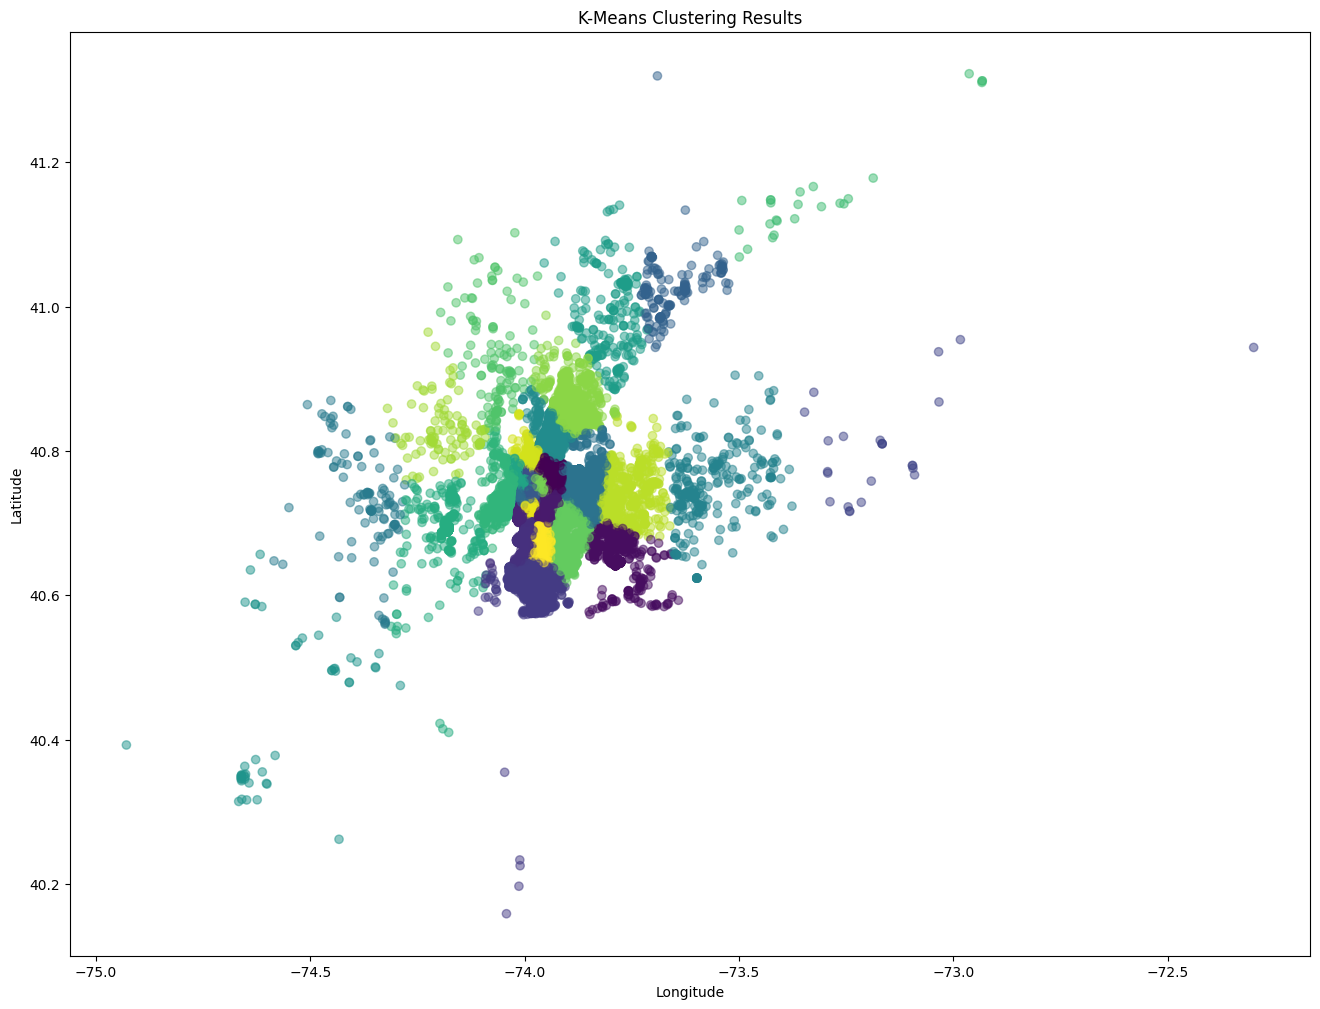

In [12]:
# K-Means Clustering
from pyspark.ml.clustering import KMeans
print("\n=== K-Means Clustering ===")
kmeans = KMeans().setK(30).setSeed(1).setFeaturesCol("features").setPredictionCol("prediction")
kmeansModel = kmeans.fit(trainingData)
kmeans_predictions = evaluate_clustering(kmeansModel, testData, "K-Means")


=== Bisecting K-Means Clustering ===
Bisecting K-Means Silhouette with squared euclidean distance = 0.34192380720818233
+----------------+-------+--------+------+------------------+----------+
|       Date/Time|    Lat|     Lon|  Base|          features|prediction|
+----------------+-------+--------+------+------------------+----------+
|5/1/2014 0:01:00| 40.694|-73.9872|B02598| [40.694,-73.9872]|         4|
|5/1/2014 0:01:00|40.7469|-73.9884|B02682|[40.7469,-73.9884]|         9|
|5/1/2014 0:02:00|40.7106|-73.9662|B02598|[40.7106,-73.9662]|         5|
|5/1/2014 0:02:00|40.7487|-74.0035|B02682|[40.7487,-74.0035]|         7|
|5/1/2014 0:02:00|40.7509|-74.0036|B02617|[40.7509,-74.0036]|         7|
+----------------+-------+--------+------+------------------+----------+
only showing top 5 rows



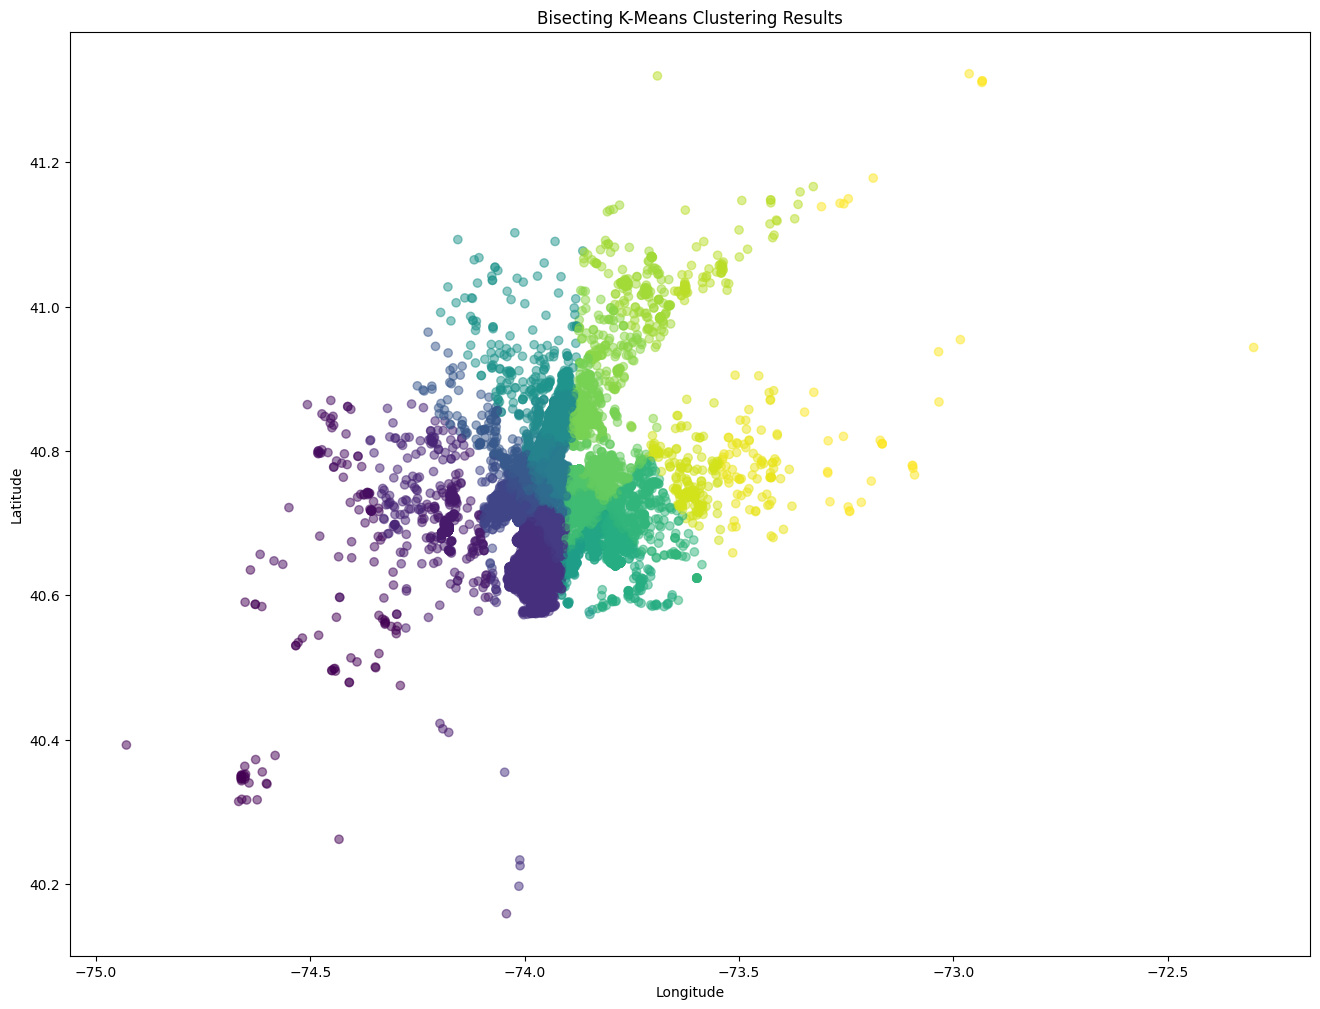

In [13]:
# Bisecting K-Means Clustering
from pyspark.ml.clustering import BisectingKMeans
print("\n=== Bisecting K-Means Clustering ===")
bkm = BisectingKMeans().setK(30).setSeed(1).setFeaturesCol("features").setPredictionCol("prediction")
bkmModel = bkm.fit(trainingData)
bkm_predictions = evaluate_clustering(bkmModel, testData, "Bisecting K-Means")

In [14]:
# Compare cluster counts
print("\n=== Cluster Distribution Comparison ===")
print("K-Means cluster distribution:")
kmeans_predictions.groupBy("prediction").count().orderBy("count", ascending=False).show(10)

print("\nBisecting K-Means cluster distribution:")
bkm_predictions.groupBy("prediction").count().orderBy("count", ascending=False).show(10)


=== Cluster Distribution Comparison ===
K-Means cluster distribution:
+----------+-----+
|prediction|count|
+----------+-----+
|        23|22020|
|        28|20966|
|         8|20132|
|         7|19800|
|        10|19388|
|         3|17066|
|         0|14775|
|        17|12384|
|        27| 7670|
|         4| 6882|
+----------+-----+
only showing top 10 rows


Bisecting K-Means cluster distribution:
+----------+-----+
|prediction|count|
+----------+-----+
|         7|46659|
|         6|26974|
|        11|25939|
|         9|18345|
|        12|15116|
|         4|10909|
|         8|10703|
|        10| 9911|
|         5| 9277|
|        13| 6494|
+----------+-----+
only showing top 10 rows



In [15]:
# Save models
kmeansModel.write().overwrite().save("uber-kmeans-model")
bkmModel.write().overwrite().save("uber-bkm-model")

In [16]:
# Test with sample data
sample_data = spark.sparkContext.parallelize([
    ("5/1/2014 0:02:00", 40.7521, -73.9914, "B02512"),
    ("5/1/2014 0:06:00", 40.6965, -73.9715, "B02512"),
    ("5/1/2014 0:15:00", 40.7464, -73.9838, "B02512"),
    ("5/1/2014 0:17:00", 40.7463, -74.0011, "B02512"),
    ("5/1/2014 0:17:00", 40.7594, -73.9734, "B02512")]
).toDF(["time", "Lat", "Lon", "base"])

sample_features = assembler.transform(sample_data)

print("\n=== Sample Data Predictions ===")
print("K-Means predictions:")
kmeansModel.transform(sample_features).show()

print("\nBisecting K-Means predictions:")
bkmModel.transform(sample_features).show()


=== Sample Data Predictions ===
K-Means predictions:
+----------------+-------+--------+------+------------------+----------+
|            time|    Lat|     Lon|  base|          features|prediction|
+----------------+-------+--------+------+------------------+----------+
|5/1/2014 0:02:00|40.7521|-73.9914|B02512|[40.7521,-73.9914]|        17|
|5/1/2014 0:06:00|40.6965|-73.9715|B02512|[40.6965,-73.9715]|        29|
|5/1/2014 0:15:00|40.7464|-73.9838|B02512|[40.7464,-73.9838]|         8|
|5/1/2014 0:17:00|40.7463|-74.0011|B02512|[40.7463,-74.0011]|        17|
|5/1/2014 0:17:00|40.7594|-73.9734|B02512|[40.7594,-73.9734]|        23|
+----------------+-------+--------+------+------------------+----------+


Bisecting K-Means predictions:
+----------------+-------+--------+------+------------------+----------+
|            time|    Lat|     Lon|  base|          features|prediction|
+----------------+-------+--------+------+------------------+----------+
|5/1/2014 0:02:00|40.7521|-73.9914|B0

In [17]:
spark.stop()